# SVM Model House Price Prediction in Zhejiang

1. Define the business and modeling objective.
2. Build a time-based preprocessing and feature engineering pipeline.
3. Train and tune an SVM regression model
4. Results with **MAE, MSE, RMSE, and R2**
5. Visualization

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Step 1 - Load Data and Confirm Time Context

**Purpose**: make sure we use the provided training period and keep the newest period as holdout testing.

create a time-based split inside training for model tuning/validation to avoid leakage from future to past.

In [2]:
"""
train_path = "use--filtered_data_train_processed_features_all_columns.csv"
test_path = "use--filtered_data_test_processed_features_all_columns.csv"

These csv files are the result of a data cleaning and processing step, then they are renamed and put to data folder:
use--filtered_data_train_processed_features_all_columns.csv = train.csv
use--filtered_data_test_processed_features_all_columns.csv = test.csv

"""

train_path = "../data/TRAIN.csv"
test_path = "../data/TEST.csv"


def read_csv_robust(path):
    for enc in ["utf-8", "utf-8-sig", "gbk", "latin1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode file: {path}")


train_df = read_csv_robust(train_path)
test_df = read_csv_robust(test_path)

for df in (train_df, test_df):
    df["Tran_Dt"] = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train period:", train_df["Tran_Dt"].min(), "to", train_df["Tran_Dt"].max())
print("Test period:", test_df["Tran_Dt"].min(), "to", test_df["Tran_Dt"].max())

Train shape: (165808, 23)
Test shape: (62733, 23)
Train period: 2012-11-22 00:00:00 to 2021-06-30 00:00:00
Test period: 2021-07-01 00:00:00 to 2023-02-13 00:00:00


## Step 2 - Feature Engineering Strategy

**Purpose**: create useful and interpretable features for model training.

### What we engineer
1. **Location blocks** (Reg, Dist, plus City for diagnostics): captures location premium and geography.
2. **Core size/structure** (Flo_Area, Tot_Flo, Total_Rooms): captures physical property scale.
3. **Building and convenience** (Build_Yr_Filled, Lift): captures age and amenity effects.
4. **Time effects** (month/quarter/year): captures market cycle changes.
5. **Simple interactions** (Area_per_Room, HighFloor_NoLift, Building_Age, Central_District): interpretable non-linear signals.

Note: after ablation checks, we keep all engineered features for analysis, but the final model intentionally drops some redundant/noisy inputs (e.g., City, Elevator_Density) to improve holdout generalization.

In [3]:
def build_features_fast(df):
    out = df.copy()

    numeric_cols = [
        "Tran_Pri", "Tran_Day", "Tot_Flo", "Flo_Area",
        "Build_Yr_Filled", "Total_Rooms", "Elevator_Density"
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Time features
    out["Tran_Year"] = out["Tran_Dt"].dt.year
    out["Tran_Month"] = out["Tran_Dt"].dt.month
    out["Tran_Quarter"] = out["Tran_Dt"].dt.quarter

    # Simple interpretable engineered features
    out["Building_Age"] = out["Tran_Year"] - out["Build_Yr_Filled"]
    out.loc[out["Building_Age"] < 0, "Building_Age"] = np.nan

    out["Has_Lift"] = (out["Lift"] == "Yes").astype(int)
    out["HighFloor_NoLift"] = ((out["Tot_Flo"] >= 10) & (out["Has_Lift"] == 0)).astype(int)

    out["Area_per_Room"] = out["Flo_Area"] / out["Total_Rooms"].replace(0, np.nan)

    central_districts = {"Shangcheng", "Gongshu", "Xihu", "Binjiang"}
    out["Central_District"] = out["Reg"].isin(central_districts).astype(int)

    return out


train_feat = build_features_fast(train_df)
test_feat = build_features_fast(test_df)

print("Engineered train shape:", train_feat.shape)
print("Engineered test shape:", test_feat.shape)

Engineered train shape: (165808, 31)
Engineered test shape: (62733, 31)


In [5]:
# Feature engineering output
engineered_cols = [
    "Tran_Dt", "City", "Reg", "Dist", "Tran_Pri",
    "Flo_Area", "Tot_Flo", "Total_Rooms", "Build_Yr_Filled", "Elevator_Density",
    "Building_Age", "Area_per_Room", "Has_Lift", "HighFloor_NoLift",
    "Central_District", "Tran_Month", "Tran_Quarter"
]

available_cols = [c for c in engineered_cols if c in train_feat.columns]

print("Engineered columns available:", len(available_cols))
display(train_feat[available_cols].head(10))

# Quick data-quality snapshot for engineered features
missing_rate = (train_feat[available_cols].isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing_rate.to_frame("Missing_%").head(15))

Engineered columns available: 17


,Tran_Dt,City,Reg,Dist,Tran_Pri,Flo_Area,Tot_Flo,Total_Rooms,Build_Yr_Filled,Elevator_Density,Building_Age,Area_per_Room,Has_Lift,HighFloor_NoLift,Central_District,Tran_Month,Tran_Quarter
0,2012-11-22,Hangzhou,Xiacheng,Zhaohui,640,38.78,7.0,2,1985.0,0.500000,27.0,19.390000,0,0,0,11,4
1,2012-11-26,Hangzhou,Xiacheng,Zhaohui,1080,54.73,7.0,3,1986.0,0.333333,26.0,18.243333,0,0,0,11,4
2,2012-12-07,Hangzhou,Xihu,Cuiyuan,1240,46.20,25.0,1,2008.0,0.285714,4.0,46.200000,1,0,1,12,4
3,2012-12-11,Hangzhou,Xiacheng,Liushuiyuan,2450,93.69,7.0,4,2010.0,0.500000,2.0,23.422500,0,0,0,12,4
4,2012-12-11,Hangzhou,Gongshu,Hushu,2000,76.86,7.0,4,1995.0,0.500000,17.0,19.215000,0,0,1,12,4
5,2012-12-14,Hangzhou,Gongshu,Desheng,1250,58.84,6.0,3,2002.0,0.333333,10.0,19.613333,0,0,1,12,4
6,2012-12-23,Hangzhou,Xiacheng,Liushuiyuan,2510,98.00,7.0,5,1996.0,0.500000,16.0,19.600000,0,0,0,12,4
7,2012-12-26,Hangzhou,Xiacheng,Liushuiyuan,1680,77.53,7.0,4,1996.0,0.333333,16.0,19.382500,0,0,0,12,4
8,2012-12-27,Hangzhou,Xihu,Wensanxilu,2600,106.27,6.0,5,2010.0,0.500000,2.0,21.254000,0,0,1,12,4
9,2012-12-27,Hangzhou,Xihu,Wensanxilu,1800,71.65,7.0,4,2000.0,0.500000,12.0,17.912500,0,0,1,12,4


,Missing_%
Area_per_Room,0.01
Building_Age,0.01
Tran_Dt,0.00
City,0.00
Reg,0.00
Flo_Area,0.00
Tot_Flo,0.00
Dist,0.00
Tran_Pri,0.00
Build_Yr_Filled,0.00


## Step 3 - Time-Based Validation Split

**Purpose**: mimic real deployment conditions with timebased validation

Sort historical training data by date and use the latest 20% as validation.
This avoids training on future records and gives a more realistic estimate of how the model generalizes over time.

In [4]:
target_col = "Tran_Pri"

train_feat[target_col] = pd.to_numeric(train_feat[target_col], errors="coerce")
test_feat[target_col] = pd.to_numeric(test_feat[target_col], errors="coerce")

train_feat = train_feat.sort_values("Tran_Dt").reset_index(drop=True)
split_idx = int(len(train_feat) * 0.8)

train_part = train_feat.iloc[:split_idx].copy()
val_part = train_feat.iloc[split_idx:].copy()

# Drop rows where target is missing after numeric conversion
train_part = train_part.dropna(subset=[target_col])
val_part = val_part.dropna(subset=[target_col])
test_feat = test_feat.dropna(subset=[target_col]).copy()

X_train = train_part.drop(columns=[target_col])
y_train = train_part[target_col]

X_val = val_part.drop(columns=[target_col])
y_val = val_part[target_col]

X_test = test_feat.drop(columns=[target_col])
y_test = test_feat[target_col]

print("Train part:", X_train.shape, y_train.shape)
print("Validation part:", X_val.shape, y_val.shape)
print("Final holdout test:", X_test.shape, y_test.shape)

Train part: (132646, 30) (132646,)
Validation part: (33162, 30) (33162,)
Final holdout test: (62733, 30) (62733,)


## Step 4 - Build SVM Pipeline with Proper Preprocessing

**Purpose**: ensure each feature type is treated correctly before SVM, preprocessing reproducible and avoids leakage.

- Numeric features: impute missing values, then standardize.
- Categorical features: impute missing values, then one-hot encode.
- Model: SVR with RBF kernel for non-linear pricing patterns.
- Target transformation: `log1p(price)` stabilizes scale and reduces extreme-value influence.


In [5]:
# Final input selection: drop redundant/noisy features found in ablation
drop_cols = ["Tran_Dt", "Neigh", "Layout", "Orient", "EA_Ratio", "City", "Elevator_Density"]
drop_cols = [c for c in drop_cols if c in X_train.columns]

X_train_model = X_train.drop(columns=drop_cols)
X_val_model = X_val.drop(columns=drop_cols)
X_test_model = X_test.drop(columns=drop_cols)

num_cols = X_train_model.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_model.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

svr = SVR(kernel="rbf")

pipe = Pipeline([
    ("prep", preprocess),
    ("svr", svr),
])

model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1,
 )

print("Dropped columns:", drop_cols)
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Dropped columns: ['Tran_Dt', 'Neigh', 'Layout', 'Orient', 'EA_Ratio', 'City', 'Elevator_Density']
Numeric columns: 14
Categorical columns: 9


## Step 5 - Hyperparameter Tuning and Final Refit

**Purpose**: tune SVM hyperparameters on a time-ordered training window, then refit the final model on a larger recent window while keeping runtime manageable.

Approach:
1. Tune hyperparameters on a capped recent window.
2. Refit the final model on a larger capped recent window with the best hyperparameters.
3. Keep time order using `TimeSeriesSplit`.

In [8]:
# Capped training with stronger tuning coverage
def recent_window(X, y, n_rows):
    if len(X) > n_rows:
        return X.iloc[-n_rows:].copy(), y.iloc[-n_rows:].copy()
    return X.copy(), y.copy()

# Stage A: tuning on capped recent window
max_svm_train_tune = 15000
X_train_svm, y_train_svm = recent_window(X_train_model, y_train, max_svm_train_tune)
print("Rows used for tuning:", len(X_train_svm))

# Slightly wider grid to reduce underfitting risk
param_grid = {
    "regressor__svr__C": [5, 10, 20, 30],
    "regressor__svr__epsilon": [0.03, 0.05, 0.1],
    "regressor__svr__gamma": [0.001, 0.003, 0.01],
}

tscv = TimeSeriesSplit(n_splits=3)
search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)
search.fit(X_train_svm, y_train_svm)

best_params = search.best_params_
print("Best params:", best_params)
print("Best CV MAE:", -search.best_score_)

# Stage B: refit final model on a larger capped recent window
max_svm_train_final = 40000
X_train_final, y_train_final = recent_window(X_train_model, y_train, max_svm_train_final)
print("Rows used for final refit:", len(X_train_final))

best_svr = SVR(
    kernel="rbf",
    C=best_params["regressor__svr__C"],
    epsilon=best_params["regressor__svr__epsilon"],
    gamma=best_params["regressor__svr__gamma"],
)

best_pipe = Pipeline([
    ("prep", preprocess),
    ("svr", best_svr),
])

best_model = TransformedTargetRegressor(
    regressor=best_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
 )

best_model.fit(X_train_final, y_train_final)

Rows used for tuning: 15000
Best params: {'regressor__svr__C': 5, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
Best CV MAE: 495.2541723330443
Rows used for final refit: 40000


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...gamma=0.01))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed ou

In [11]:
# Save the tuned best model for reuse/deployment
import joblib

model_output_path = "best_svm_model.joblib"
joblib.dump(best_model, model_output_path)

print(f"Best model saved to: {model_output_path}")

Best model saved to: best_svm_model.joblib


In [6]:
# Load saved model and preview actual vs predicted prices
import joblib
loaded_model = joblib.load("best_svm_model.joblib")

loaded_test_pred = loaded_model.predict(X_test_model)

preview_df = pd.DataFrame({
    "Tran_Pri_Actual": y_test.values,
    "Tran_Pri_Predicted": loaded_test_pred,
})

# Optional context columns
if "Tran_Dt" in X_test.columns:
    preview_df.insert(0, "Tran_Dt", pd.to_datetime(X_test["Tran_Dt"]).values)
if "City" in X_test.columns:
    preview_df.insert(1 if "Tran_Dt" in preview_df.columns else 0, "City", X_test["City"].values)
if "Reg" in X_test.columns:
    preview_df["Reg"] = X_test["Reg"].values
if "Dist" in X_test.columns:
    preview_df["Dist"] = X_test["Dist"].values
if "Neigh" in X_test.columns:
    preview_df["Neigh"] = X_test["Neigh"].values

# Build a readable property label for charts (fallback if some fields are missing)
label_parts = []
for col in ["City", "Reg", "Dist", "Neigh"]:
    if col in preview_df.columns:
        label_parts.append(preview_df[col].fillna("Unknown").astype(str))

if label_parts:
    preview_df["Property_Label"] = label_parts[0]
    for part in label_parts[1:]:
        preview_df["Property_Label"] = preview_df["Property_Label"] + " | " + part
else:
    preview_df["Property_Label"] = [f"Record {i}" for i in range(len(preview_df))]

preview_df["Abs_Error"] = (preview_df["Tran_Pri_Actual"] - preview_df["Tran_Pri_Predicted"]).abs()

display(preview_df.head(15))

,Tran_Dt,City,Tran_Pri_Actual,Tran_Pri_Predicted,Reg,Dist,Neigh,Property_Label,Abs_Error
0,2021-07-01,Hangzhou,2130,2986.356657,Qiantangqu,Jinshahu,Dejiajinshayangguang,Hangzhou | Qiantangqu | Jinshahu | Dejiajinsha...,856.356657
1,2021-07-01,Hangzhou,1900,1782.655977,Gongshu,Daguan,Daguanxiqiyuan,Hangzhou | Gongshu | Daguan | Daguanxiqiyuan,117.344023
2,2021-07-01,Ningbo,3160,3650.185655,Jiangbeiqu,Jiangbeiwanda,Yinyiyudingyuan,Ningbo | Jiangbeiqu | Jiangbeiwanda | Yinyiyud...,490.185655
3,2021-07-01,Ningbo,3250,1924.542707,Beilunqu,Xinqi,Sijiguihuayuanyiguiyuan,Ningbo | Beilunqu | Xinqi | Sijiguihuayuanyigu...,1325.457293
4,2021-07-01,Hangzhou,5400,5113.325188,Xihu,Sandun,Jindizizaichengmanaowan,Hangzhou | Xihu | Sandun | Jindizizaichengmana...,286.674812
5,2021-07-01,Hangzhou,2900,2846.174340,Fuyang,Dongzhou,Rongchuangweifengzhicheng,Hangzhou | Fuyang | Dongzhou | Rongchuangweife...,53.825660
6,2021-07-01,Hangzhou,3100,3209.555055,Yuhang,Weilaikejicheng,Beidaziyuanweimingfu,Hangzhou | Yuhang | Weilaikejicheng | Beidaziy...,109.555055
7,2021-07-01,Hangzhou,2250,2470.600817,Gongshu,Jianguobeilu,Dongyuanxiaoqu,Hangzhou | Gongshu | Jianguobeilu | Dongyuanxi...,220.600817
8,2021-07-01,Hangzhou,2770,2504.141453,Yuhang,Liangzhu,Kunlunhuafu,Hangzhou | Yuhang | Liangzhu | Kunlunhuafu,265.858547
9,2021-07-01,Shaoxing,2920,2154.163990,Shangyuqu,Shangyuchengxi,Runtu Jiaheyuan,Shaoxing | Shangyuqu | Shangyuchengxi | Runtu ...,765.836010


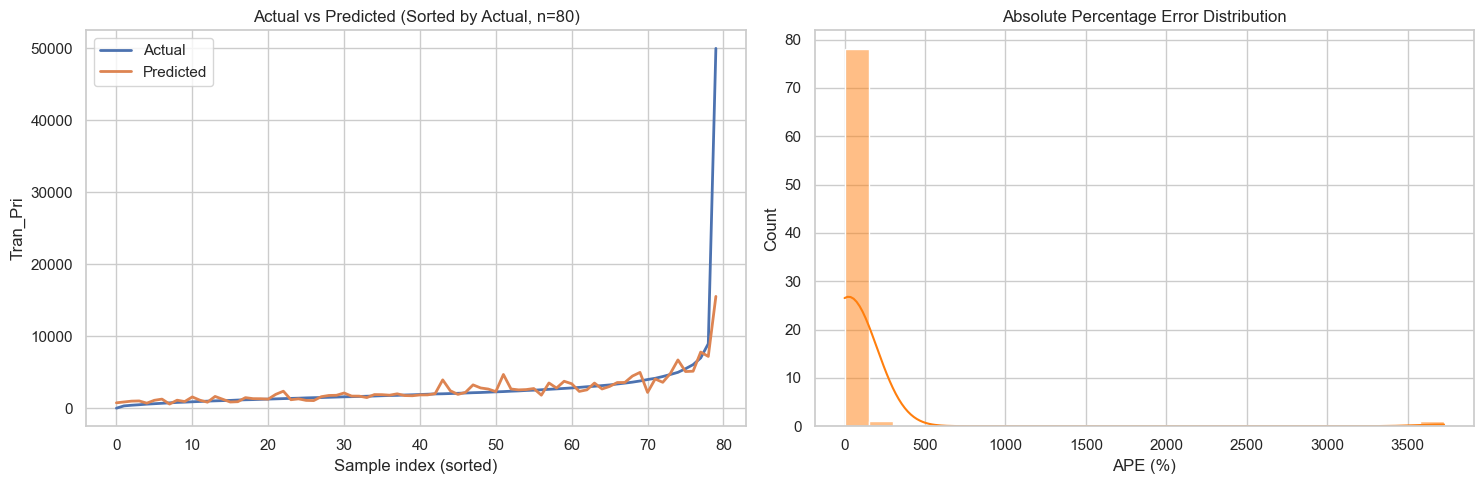

Median APE (%): 16.23
P90 APE (%): 74.39
Interpretation: lower APE and lower P90 APE indicate better prediction accuracy and better tail-case reliability.


In [8]:
# Visualization for predicted vs actual values (less misleading ordering + relative error)
viz_df = preview_df.copy().dropna(subset=["Tran_Pri_Actual", "Tran_Pri_Predicted"]).reset_index(drop=True)

# Sort by actual price so the comparison is easier to read
sorted_df = viz_df.sort_values("Tran_Pri_Actual").reset_index(drop=True)
n_show = min(80, len(sorted_df))

if len(sorted_df) > n_show:
    idx = np.linspace(0, len(sorted_df) - 1, n_show).astype(int)
    plot_slice = sorted_df.iloc[idx].copy().reset_index(drop=True)
else:
    plot_slice = sorted_df.copy()

plot_slice["Abs_Error"] = (plot_slice["Tran_Pri_Actual"] - plot_slice["Tran_Pri_Predicted"]).abs()

# APE (Absolute Percentage Error) = |Actual - Predicted| / |Actual| * 100
# This converts absolute error into percentage form so errors are comparable across price levels.
plot_slice["APE_%"] = (plot_slice["Abs_Error"] / plot_slice["Tran_Pri_Actual"].clip(lower=1)) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: actual vs predicted line after sorting by actual
axes[0].plot(plot_slice.index, plot_slice["Tran_Pri_Actual"], label="Actual", linewidth=2)
axes[0].plot(plot_slice.index, plot_slice["Tran_Pri_Predicted"], label="Predicted", linewidth=2)
axes[0].set_title(f"Actual vs Predicted (Sorted by Actual, n={len(plot_slice)})")
axes[0].set_xlabel("Sample index (sorted)")
axes[0].set_ylabel("Tran_Pri")
axes[0].legend()

# Right: distribution of APE (%) to show relative error spread
sns.histplot(plot_slice["APE_%"], bins=25, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Absolute Percentage Error Distribution")
axes[1].set_xlabel("APE (%)")

plt.tight_layout()
plt.show()

median_ape = plot_slice["APE_%"].median()
p90_ape = plot_slice["APE_%"].quantile(0.9)

# P90 APE = 90th percentile of APE values.
# Interpretation: 90% of predictions have APE <= P90 APE; lower is better.
print("Median APE (%):", round(median_ape, 2))
print("P90 APE (%):", round(p90_ape, 2))
print("Interpretation: lower APE and lower P90 APE indicate better prediction accuracy and better tail-case reliability.")

## Step 6 - Result with MAE, MSE, RMSE, and R2

**Purpose**: produce the exact metrics results

- Validation set: checks whether tuning worked on recent historical data.
- Test set: final performance on the newest unseen period.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Relative error metrics for scale-aware interpretation
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    safe_true = np.clip(np.abs(y_true_arr), 1e-9, None)
    mape = np.mean(np.abs((y_true_arr - y_pred_arr) / safe_true)) * 100
    smape = np.mean(2 * np.abs(y_true_arr - y_pred_arr) / (np.abs(y_true_arr) + np.abs(y_pred_arr) + 1e-9)) * 100

    return mae, mse, rmse, r2, mape, smape

# Use tuned model if available; otherwise use loaded saved model
if "best_model" in globals():
    eval_model = best_model
elif "loaded_model" in globals():
    eval_model = loaded_model
else:
    raise NameError("No model found. Run tuning cell or load-model cell first.")

val_pred = eval_model.predict(X_val_model)
test_pred = eval_model.predict(X_test_model)

# Explicit sanity check: if model is TransformedTargetRegressor,
# predictions should already be inverse-transformed back to original price units.
inverse_check_note = "Not checked"
if hasattr(eval_model, "regressor_") and hasattr(eval_model, "inverse_func"):
    n_check = min(200, len(X_val_model))
    raw_log_pred = eval_model.regressor_.predict(X_val_model.iloc[:n_check])
    restored_pred = eval_model.inverse_func(raw_log_pred)
    inverse_ok = np.allclose(restored_pred, val_pred[:n_check], rtol=1e-6, atol=1e-6)
    inverse_check_note = f"inverse_transform_verified={inverse_ok}"

val_metrics = regression_metrics(y_val, val_pred)
test_metrics = regression_metrics(y_test, test_pred)

metrics_df = pd.DataFrame({
    "Dataset": ["Validation (last 20% of train)", "Holdout Test (latest years)"],
    "MAE": [val_metrics[0], test_metrics[0]],
    "MSE": [val_metrics[1], test_metrics[1]],
    "RMSE": [val_metrics[2], test_metrics[2]],
    "R2": [val_metrics[3], test_metrics[3]],
    "MAPE_%": [val_metrics[4], test_metrics[4]],
    "SMAPE_%": [val_metrics[5], test_metrics[5]],
})

metrics_df["Absolute_Metric_Unit"] = "Original Tran_Pri unit (inverse log applied)"
metrics_df["Transform_Check"] = inverse_check_note

metrics_df

,Dataset,MAE,MSE,RMSE,R2,MAPE_%,SMAPE_%,Absolute_Metric_Unit,Transform_Check
0,Validation (last 20% of train),384.427396,567340.830060,753.220306,0.826184,16.767832,15.805361,Original Tran_Pri unit (inverse log applied),inverse_transform_verified=True
1,Holdout Test (latest years),503.034257,852560.035805,923.341776,0.773228,25.865461,21.553533,Original Tran_Pri unit (inverse log applied),inverse_transform_verified=True


## Step 7 - Visualizations

**Purpose**: explain model behavior and data patterns 

These charts help answer:
- Is the market trend changing over time?
- Does the model systematically over/under-predict?
- Which groups (e.g., cities) are harder to predict?

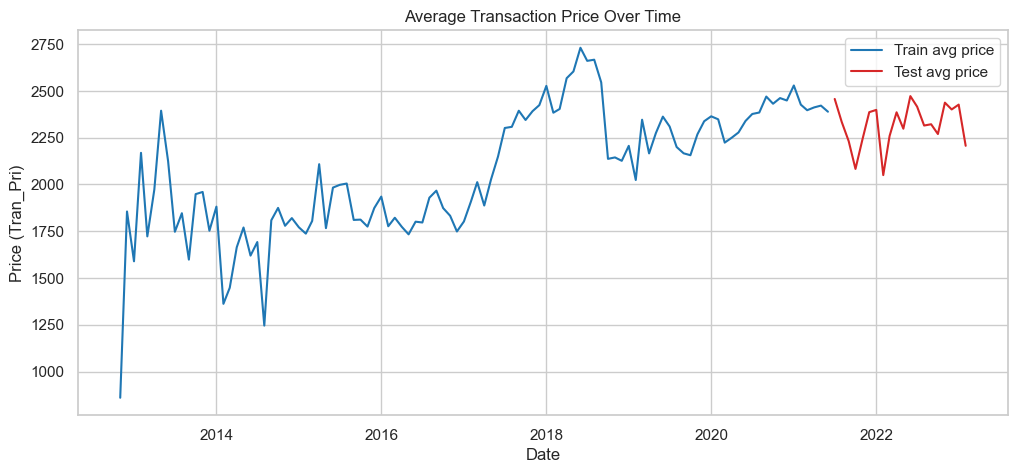

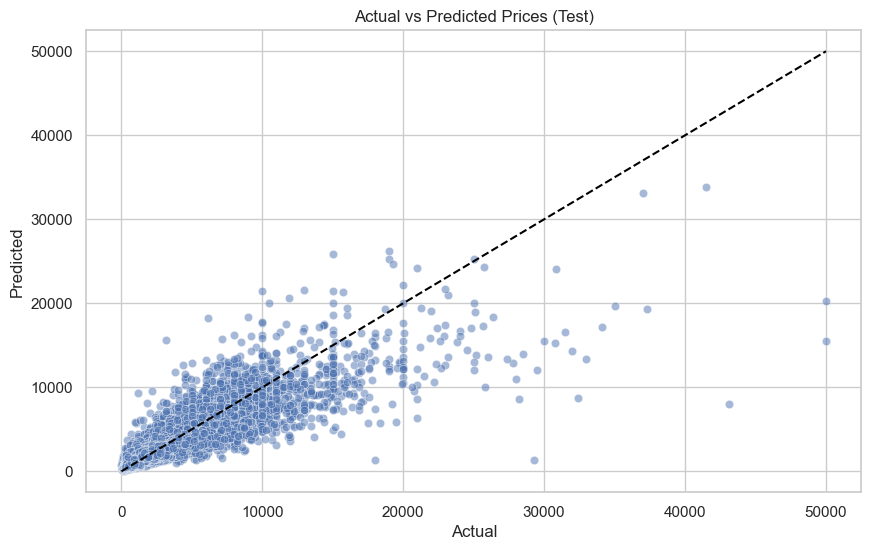

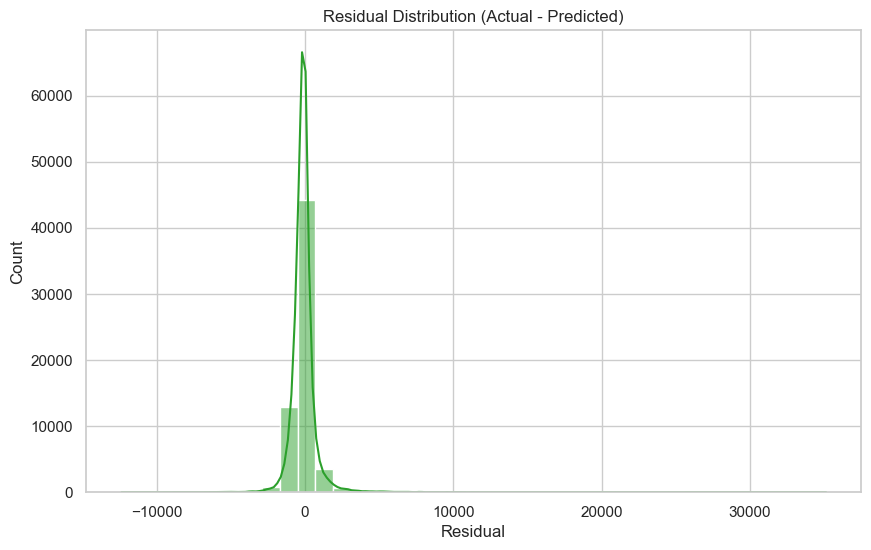

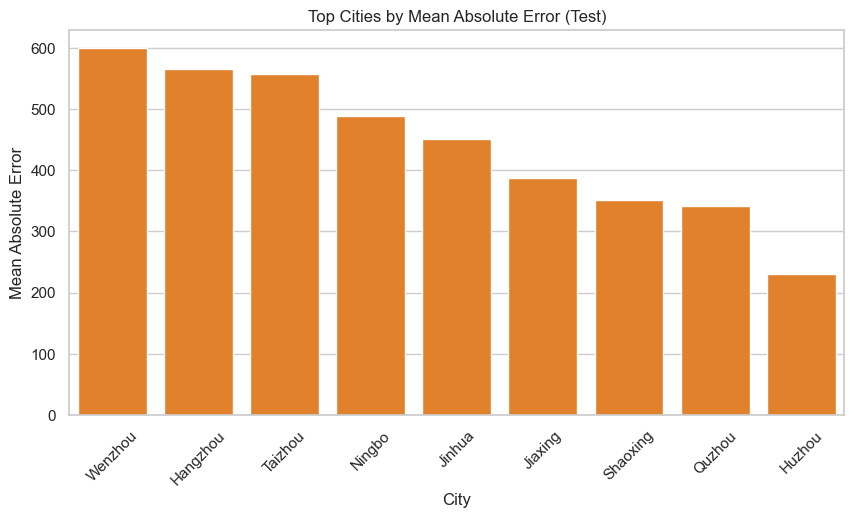

In [15]:
# 1) Transaction price trend over time (train vs test)
train_month = train_feat.groupby(train_feat["Tran_Dt"].dt.to_period("M"))["Tran_Pri"].mean().reset_index()
test_month = test_feat.groupby(test_feat["Tran_Dt"].dt.to_period("M"))["Tran_Pri"].mean().reset_index()

train_month["Tran_Dt"] = train_month["Tran_Dt"].dt.to_timestamp()
test_month["Tran_Dt"] = test_month["Tran_Dt"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_month["Tran_Dt"], train_month["Tran_Pri"], label="Train avg price", color="#1f77b4")
ax.plot(test_month["Tran_Dt"], test_month["Tran_Pri"], label="Test avg price", color="#d62728")
ax.set_title("Average Transaction Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Price (Tran_Pri)")
ax.legend()
plt.show()

# 2) Actual vs Predicted on holdout test
plot_df = pd.DataFrame({"Actual": y_test, "Predicted": test_pred})

fig, ax = plt.subplots()
sns.scatterplot(data=plot_df, x="Actual", y="Predicted", alpha=0.5, ax=ax)
line_min = min(plot_df["Actual"].min(), plot_df["Predicted"].min())
line_max = max(plot_df["Actual"].max(), plot_df["Predicted"].max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
ax.set_title("Actual vs Predicted Prices (Test)")
plt.show()

# 3) Residual distribution and error by city
residuals = y_test - test_pred

fig, ax = plt.subplots()
sns.histplot(residuals, bins=40, kde=True, ax=ax, color="#2ca02c")
ax.set_title("Residual Distribution (Actual - Predicted)")
ax.set_xlabel("Residual")
plt.show()

city_error = pd.DataFrame({
    "City": test_feat["City"].values,
    "AE": np.abs(residuals)
})
city_mae = city_error.groupby("City")["AE"].mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=city_mae.index, y=city_mae.values, ax=ax, color="#ff7f0e")
ax.set_title("Top Cities by Mean Absolute Error (Test)")
ax.set_ylabel("Mean Absolute Error")
ax.tick_params(axis="x", rotation=45)
plt.show()

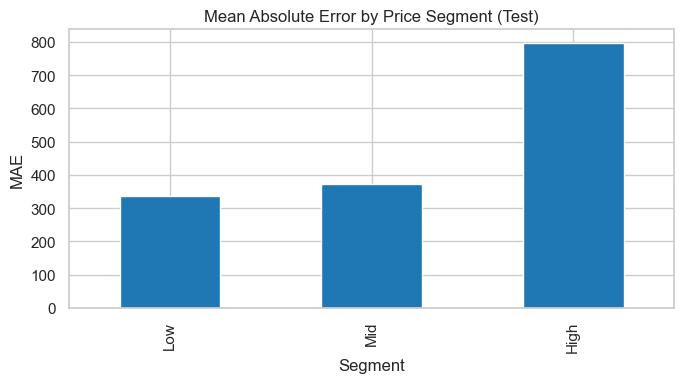

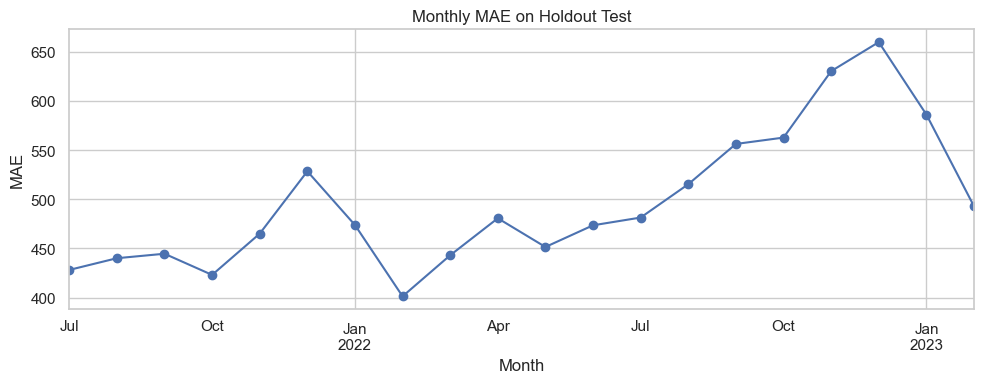

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 4) Error by price segment (low/mid/high)
segment_labels = ["Low", "Mid", "High"]
price_quantiles = pd.qcut(y_test.rank(method="first"), q=3, labels=segment_labels)
segment_df = pd.DataFrame({
    "Segment": price_quantiles,
    "Abs_Error": np.abs(y_test - test_pred)
})
segment_mae = segment_df.groupby("Segment")["Abs_Error"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
segment_mae.plot(kind="bar", color="#1f77b4", ax=ax)
ax.set_title("Mean Absolute Error by Price Segment (Test)")
ax.set_ylabel("MAE")
plt.tight_layout()
plt.show()

# 5) Error over time (monthly MAE)
monthly_mae = pd.DataFrame({
    "Month": test_feat["Tran_Dt"].dt.to_period("M"),
    "Abs_Error": np.abs(y_test - test_pred)
}).groupby("Month")["Abs_Error"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_mae.plot(ax=ax, marker="o")
ax.set_title("Monthly MAE on Holdout Test")
ax.set_ylabel("MAE")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

## Step 7B - Feature Importance and Effect on Predictions

**Purpose**: quantify which features matter most (ranking) and show how top features influence predicted price directionally.

Method used: **Permutation Importance** (model-agnostic).
- Higher importance means prediction quality drops more when that feature is shuffled.
- Effect plots show whether higher feature values/categories are associated with higher or lower predicted prices.

Using model for importance: best_model
Permutation importance source: Validation set, rows=4000


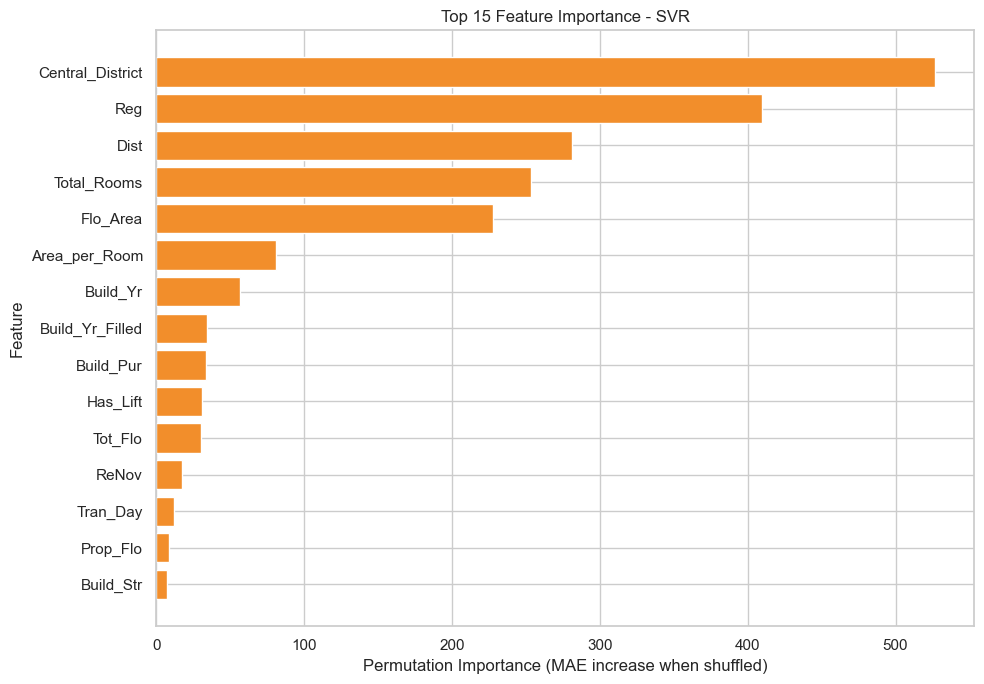

Top features by permutation importance:


,Feature,Importance,Std
22,Central_District,526.7345,15.0722
0,Reg,409.4306,9.0376
1,Dist,281.2172,3.9429
13,Total_Rooms,253.4687,7.2550
5,Flo_Area,227.5553,11.0637
21,Area_per_Room,81.4003,2.7169
7,Build_Yr,56.9781,2.1696
14,Build_Yr_Filled,34.6189,2.3228
12,Build_Pur,33.4356,2.9649
19,Has_Lift,31.0628,1.6434



Feature effect summary (based on model predictions):
- Central_District: higher predicted price in '1' than '0'
- Reg: higher predicted price in 'Xihu' than 'Linpingqu'
- Dist: higher predicted price in 'Liangzhu' than 'Nanhuqu'
- Total_Rooms: positive relationship (Spearman=0.513)
- Flo_Area: positive relationship (Spearman=0.550)
- Area_per_Room: positive relationship (Spearman=0.205)


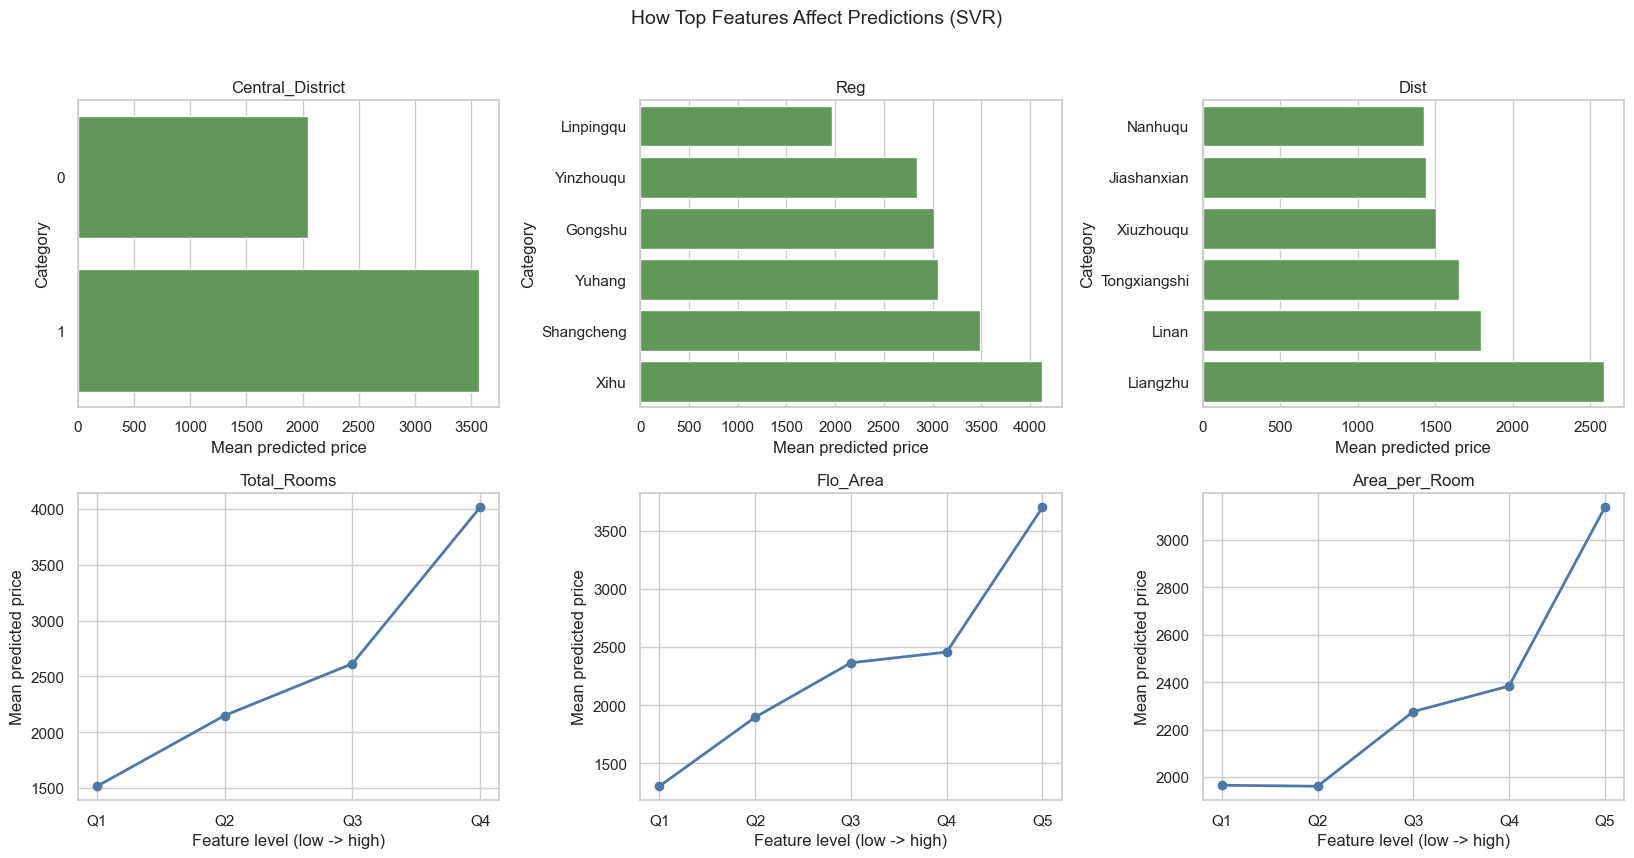

In [10]:
from sklearn.inspection import permutation_importance

# Use the best available trained model object from earlier steps.
# Priority: best_model (tuned) -> loaded_model (joblib) -> eval_model (fallback)
model_for_importance = None
for candidate in ["best_model", "loaded_model", "eval_model"]:
    if candidate in globals():
        model_for_importance = globals()[candidate]
        print(f"Using model for importance: {candidate}")
        break

if model_for_importance is None:
    raise RuntimeError("No trained model found. Please run training/evaluation cells first.")

# Use validation set by default; fall back to test set if needed.
if "X_val_model" in globals() and "y_val" in globals():
    X_imp = X_val_model.copy()
    y_imp = y_val.copy()
    source_name = "Validation"
elif "X_test_model" in globals() and "y_test" in globals():
    X_imp = X_test_model.copy()
    y_imp = y_test.copy()
    source_name = "Holdout Test"
else:
    raise RuntimeError("No evaluation dataset found. Please run the data split/feature cells first.")

# Sample to keep runtime practical while preserving ranking quality.
MAX_ROWS_IMPORTANCE = 4000
if len(X_imp) > MAX_ROWS_IMPORTANCE:
    sampled_idx = X_imp.sample(n=MAX_ROWS_IMPORTANCE, random_state=42).index
    X_imp = X_imp.loc[sampled_idx]
    y_imp = y_imp.loc[sampled_idx]

print(f"Permutation importance source: {source_name} set, rows={len(X_imp)}")

perm = permutation_importance(
    estimator=model_for_importance,
    X=X_imp,
    y=y_imp,
    n_repeats=4,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "Feature": X_imp.columns,
        "Importance": perm.importances_mean,
        "Std": perm.importances_std,
    }
).sort_values("Importance", ascending=False)

# Keep positive contributions at top for clearer interpretation.
importance_df_pos = importance_df[importance_df["Importance"] > 0].copy()
if importance_df_pos.empty:
    importance_df_pos = importance_df.copy()

TOP_K = 15
top_importance = importance_df_pos.head(TOP_K).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_importance["Feature"], top_importance["Importance"], color="#f28e2b")
plt.xlabel("Permutation Importance (MAE increase when shuffled)")
plt.ylabel("Feature")
plt.title(f"Top {min(TOP_K, len(top_importance))} Feature Importance - SVR")
plt.tight_layout()
plt.show()

print("Top features by permutation importance:")
display(importance_df.head(20).round(4))

# -------- Feature effect view (direction/shape) --------
pred_imp = pd.Series(model_for_importance.predict(X_imp), index=X_imp.index, name="predicted")

top_features_for_effect = importance_df_pos["Feature"].head(6).tolist()
if len(top_features_for_effect) == 0:
    top_features_for_effect = importance_df["Feature"].head(6).tolist()

n_plots = len(top_features_for_effect)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

print("\nFeature effect summary (based on model predictions):")
for i, f in enumerate(top_features_for_effect):
    ax = axes[i]
    s = X_imp[f]

    # Numeric feature: plot trend across quantile bins.
    if pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) >= 8:
        tmp = pd.DataFrame({"feature": s, "pred": pred_imp}).dropna()
        tmp["bin"] = pd.qcut(tmp["feature"], q=5, duplicates="drop")
        prof = tmp.groupby("bin", observed=False)["pred"].mean().reset_index()

        ax.plot(range(len(prof)), prof["pred"], marker="o", linewidth=2, color="#4e79a7")
        ax.set_xticks(range(len(prof)))
        ax.set_xticklabels([f"Q{j+1}" for j in range(len(prof))])
        ax.set_xlabel("Feature level (low -> high)")
        ax.set_ylabel("Mean predicted price")
        ax.set_title(f)

        corr = tmp["feature"].corr(tmp["pred"], method="spearman")
        if pd.notna(corr):
            direction = "positive" if corr > 0 else "negative"
            print(f"- {f}: {direction} relationship (Spearman={corr:.3f})")
        else:
            print(f"- {f}: relationship could not be estimated")

    # Categorical / low-cardinality feature: compare mean prediction by category.
    else:
        tmp = pd.DataFrame({"feature": s.astype(str), "pred": pred_imp}).dropna()
        keep = tmp["feature"].value_counts().head(6).index
        prof = tmp[tmp["feature"].isin(keep)].groupby("feature")["pred"].mean().sort_values(ascending=True)

        sns.barplot(x=prof.values, y=prof.index, ax=ax, color="#59a14f")
        ax.set_xlabel("Mean predicted price")
        ax.set_ylabel("Category")
        ax.set_title(f)

        if len(prof) >= 2:
            print(f"- {f}: higher predicted price in '{prof.index[-1]}' than '{prof.index[0]}'")
        else:
            print(f"- {f}: limited category variation in sampled data")

# Hide unused subplot axes
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.suptitle("How Top Features Affect Predictions (SVR)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Step 8 - Business Recommendation and Customer Perspective

**Purpose**: connect the model output to a practical recommendation for the customer and business use case.

### Customer-facing recommendation
- Use this SVM model as a **decision-support tool** for housing price estimation, not as an exact final selling price.
- The model is most reliable for **typical properties** with common features and normal market conditions.
- For expensive, unusual, or highly customized properties, the prediction should be treated with extra caution because the error can be larger.
- For a buyer, the model is most useful to check whether a house looks **fairly priced, overpriced, or underpriced** compared with similar properties.

### What the feature engineering means for the buyer
- **Location effect**: `Central_District = 1` usually indicates a more desirable area, so the expected price is higher. This is useful because buyers usually pay more for better location and stronger access to services.
- **Building convenience**: `HighFloor_NoLift = 1` usually means the property is less convenient, so the expected price is lower than a similar property with a lift. This matters for buyers because comfort and accessibility affect long-term value.
- **Building age**: a larger `Building_Age` often means older construction and possible depreciation, so the price expectation is usually lower than for newer buildings.
- **Floor area**: larger floor area usually increases the total house price. However, buyers should also consider price efficiency, because a bigger house is not always better if the price rises too much per square meter.
- **Room efficiency**: `Area_per_Room` helps show how spacious the layout is. A higher value can mean more comfortable rooms, while a lower value can mean a more crowded layout.
- **Market timing**: `Tran_Year`, `Tran_Month`, and `Tran_Quarter` capture time trends, which matter because housing prices can rise or fall across different periods.

### How a buyer can use these insights
- If a property is in a central district, has a lift, and is relatively new, it is more likely to justify a higher asking price.
- If a property has a large floor area, the total price may be higher, but the buyer should still compare the price with nearby similar homes to see if the unit is actually good value.
- If the property is old, high-floor without a lift, or in a less central area, the buyer should expect a lower fair price and negotiate more carefully.
- The model can help the buyer compare two similar homes and decide which one gives better value for money.

### How the model can be used in practice
- A customer or analyst can input property attributes into the trained pipeline and get a predicted price.
- The model can help compare whether a property is overpriced or underpriced relative to similar homes.
- It can support pricing, negotiation, and portfolio screening decisions.
- Because housing markets change over time, the model should be **retrained regularly** with newer transaction data.

### Final conclusion
- The SVM model gives a useful baseline for housing price prediction.
- It performs reasonably well on normal cases, but errors increase for difficult or high-value properties.
- Therefore, it is suitable for **supporting pricing decisions**, but not yet strong enough to be the only model for precise future pricing without regular updates and monitoring.